# GLUP24 EDA - Anàlisi Exploratori de dades

En aquest notebook s'analitza de forma detallada, des de la entrada de les dades sense processar i es fa un anàlisis exploratori de les dades que posteriorment haurem de entrenar per tal de predir la glucosa dels pacients (preprocessamaent i entrenament realitzat en el notebook `offline_glucosa.ipynb`). Anàlitzarem les dades de un dels pacients per tal de posteriorment poder-ho extrapolar a la resta.

#### Import de llibreries i warnings

In [158]:
# Exploració de dades
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)

## Estructura dataset

In [159]:
# Definim les columnes per tal de poder analitzar millor el dataset, segons l'arxiu data/columns_description.txt
cols = [
    'year', 'month', 'day', 'hour', 'minute', 'second', # A–F
    'glucose_level', # G
    'finger_stick', # H
    'basal', # I
    'bolus', # J
    'sleep', # K
    'work', # L
    'stressors', # M
    'hypo_event', # N
    'illness', # O
    'exercise', # P
    'basis_heart_rate', # Q
    'basis_gsr', # R
    'basis_skin_temperature', # S
    'basis_air_temperature',  # T
    'basis_step', # U
    'basis_sleep', # V
    'meal', # W
    'meal_type' # X
]

In [160]:
# Lectura del dataset, afegint les columnes descrites anteriorment com a header i separant amb ; per detectar el dataset de forma correcta
df_559_train = pd.read_csv('../data/559/559_train.csv', sep=';', header=None, names=cols)
df_559_test = pd.read_csv('../data/559/559_test.csv', sep=';', header=None, names=cols)

# Display del train
print(df_559_train.shape)
display(df_559_train.head())
display(df_559_train.tail())

# Display del test
print(df_559_test.shape)
display(df_559_test.head())
display(df_559_test.tail())

df_559_train.info()

(12083, 24)


,year,month,day,hour,minute,second,glucose_level,finger_stick,basal,bolus,sleep,work,stressors,hypo_event,illness,exercise,basis_heart_rate,basis_gsr,basis_skin_temperature,basis_air_temperature,basis_step,basis_sleep,meal,meal_type
0,2021,12,7,1,5,0,0,107,"0,65","1,6",0,0,0,0,0,0,0,0,0,0,0,0,25,0
1,2021,12,7,1,10,0,0,0,"0,65",0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,2021,12,7,1,15,0,101,0,"0,65",0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,2021,12,7,1,20,0,98,0,"0,65",0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,2021,12,7,1,25,0,104,0,"0,65",0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


,year,month,day,hour,minute,second,glucose_level,finger_stick,basal,bolus,sleep,work,stressors,hypo_event,illness,exercise,basis_heart_rate,basis_gsr,basis_skin_temperature,basis_air_temperature,basis_step,basis_sleep,meal,meal_type
12078,2022,1,17,23,35,0,161,0,"0,83",0,3,0,0,0,0,0,58,"0,000213","92,3","89,6",0,94,0,0
12079,2022,1,17,23,40,0,164,0,"0,83",0,3,0,0,0,0,0,58,"0,000201","92,3","89,6",0,94,0,0
12080,2022,1,17,23,45,0,168,0,"0,83",0,3,0,0,0,0,0,58,"0,000198","92,3","89,6",0,94,0,0
12081,2022,1,17,23,50,0,172,0,"0,83",0,3,0,0,0,0,0,57,"0,000192","92,3","89,6",0,94,0,0
12082,2022,1,17,23,55,0,176,0,"0,83",0,3,0,0,0,0,0,58,"0,000188","92,3","89,6",0,94,0,0


(2876, 24)


,year,month,day,hour,minute,second,glucose_level,finger_stick,basal,bolus,sleep,work,stressors,hypo_event,illness,exercise,basis_heart_rate,basis_gsr,basis_skin_temperature,basis_air_temperature,basis_step,basis_sleep,meal,meal_type
0,2022,1,18,0,0,0,179,0,"0,83",0,3,0,0,0,0,0,57,"0,000183","92,3","89,6",0,94,0,0
1,2022,1,18,0,5,0,183,0,"0,83",0,3,0,0,0,0,0,57,"0,000182","92,3","89,6",0,94,0,0
2,2022,1,18,0,10,0,187,0,"0,83",0,3,0,0,0,0,0,57,"0,000177","92,3","89,6",0,94,0,0
3,2022,1,18,0,15,0,191,0,"0,83",0,3,0,0,0,0,0,56,"0,000169","92,3","89,6",0,94,0,0
4,2022,1,18,0,20,0,195,0,"0,83",0,3,0,0,0,0,0,56,"0,000166","92,3","89,6",0,94,0,0


,year,month,day,hour,minute,second,glucose_level,finger_stick,basal,bolus,sleep,work,stressors,hypo_event,illness,exercise,basis_heart_rate,basis_gsr,basis_skin_temperature,basis_air_temperature,basis_step,basis_sleep,meal,meal_type
2871,2022,1,27,23,15,0,185,0,"1,25",0,3,0,0,0,0,0,0,0,0,0,0,0,0,0
2872,2022,1,27,23,20,0,183,0,"1,25",0,3,0,0,0,0,0,0,0,0,0,0,0,0,0
2873,2022,1,27,23,25,0,182,0,"1,25",0,3,0,0,0,0,0,0,0,0,0,0,0,0,0
2874,2022,1,27,23,30,0,180,0,"1,25",0,3,0,0,0,0,0,0,0,0,0,0,0,0,0
2875,2022,1,27,23,35,0,177,0,"1,25",0,3,0,0,0,0,0,0,0,0,0,0,0,0,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12083 entries, 0 to 12082
Data columns (total 24 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   year                    12083 non-null  int64 
 1   month                   12083 non-null  int64 
 2   day                     12083 non-null  int64 
 3   hour                    12083 non-null  int64 
 4   minute                  12083 non-null  int64 
 5   second                  12083 non-null  int64 
 6   glucose_level           12083 non-null  int64 
 7   finger_stick            12083 non-null  int64 
 8   basal                   12083 non-null  object
 9   bolus                   12083 non-null  object
 10  sleep                   12083 non-null  int64 
 11  work                    12083 non-null  int64 
 12  stressors               12083 non-null  int64 
 13  hypo_event              12083 non-null  int64 
 14  illness                 12083 non-null  int64 
 15  ex

Es pot comprovar que efectivament el dataset del train acaba just on comença el test

Les dades es registren cada 5 minuts (es pot veure per la columna 'minute' i la diferència entre files consecutives). Per tant l'unitat base seran els 5 minuts.

 La variable objectiu, glucose_level està present. A df.info() apareix com a int64, però ja veiem a df.head() que té valors com 0, la qual cosa requerirà un tractament posterior, ja que 0 no és un nivell de glucosa fisiològic. S'haura de mirar altres possible features que passii el mateix.

In [161]:
# Percentatge de valors nuls
print('Percentatge de valors nuls:', '\n')
print(df_559_train.isnull().mean()*100)

Percentatge de valors nuls: 

year                      0.0
month                     0.0
day                       0.0
hour                      0.0
minute                    0.0
second                    0.0
glucose_level             0.0
finger_stick              0.0
basal                     0.0
bolus                     0.0
sleep                     0.0
work                      0.0
stressors                 0.0
hypo_event                0.0
illness                   0.0
exercise                  0.0
basis_heart_rate          0.0
basis_gsr                 0.0
basis_skin_temperature    0.0
basis_air_temperature     0.0
basis_step                0.0
basis_sleep               0.0
meal                      0.0
meal_type                 0.0
dtype: float64


Inicialment veiem que no hi ha valors nuls, però això no significa que no hi hagi valors erronis en el datset, per exemple aquest valors de 0 nivell de glucosa, un valor implausible

In [162]:
# Dividim el train (com a exemple) ja que és una porció gran de les dades per observar la distribució general del dataset
print('Estructura: ', df_559_train.shape)

num_col=df_559_train.select_dtypes(include=[np.number]).columns
cat_col = df_559_train.select_dtypes(exclude=[np.number]).columns

print(f'Columnes numèriques: {num_col.shape[0]} \n{num_col.tolist()} \n\nColumnes categòriques: {cat_col.shape[0]} \n{cat_col.tolist()}')


Estructura:  (12083, 24)
Columnes numèriques: 19 
['year', 'month', 'day', 'hour', 'minute', 'second', 'glucose_level', 'finger_stick', 'sleep', 'work', 'stressors', 'hypo_event', 'illness', 'exercise', 'basis_heart_rate', 'basis_step', 'basis_sleep', 'meal', 'meal_type'] 

Columnes categòriques: 5 
['basal', 'bolus', 'basis_gsr', 'basis_skin_temperature', 'basis_air_temperature']


In [163]:
# Anteriorment en el df.info() he pogut observar que hi ha diferentes columnes que es marquen com a categoriques que realment no 
# té gaire lògica que es marquin com a tal. I d'altres de numèriques que podrien semblar categòriques. 

# Observem quin tipo de valors tenen les columnes les quals estic dubtant
for col in ['basal','bolus','basis_gsr','basis_skin_temperature','basis_air_temperature', 'meal_type', 'sleep', 'work', 'stressors', 'hypo_event', 'illness', 'exercise']: # Incluim meal_type ja que hauria de ser catagorica
    print('--'*50,'\n', df_559_train[col].value_counts())

---------------------------------------------------------------------------------------------------- 
 basal
1,25    4230
0,9     1778
1,15    1583
0,65    1306
0,73    1045
0,83     835
0,88     690
0        616
Name: count, dtype: int64
---------------------------------------------------------------------------------------------------- 
 bolus
0      11932
3,3       12
5,5       10
2,7        9
4,4        8
5          7
3,8        7
6,6        6
7,2        4
2          4
1,6        4
2,2        4
6,5        3
2,5        3
2,4        3
0,8        3
2,3        3
4,1        3
3          3
3,9        3
1,1        2
0,1        2
6,1        2
4,2        2
6,3        2
0,6        2
0,3        2
4          2
1,7        2
2,9        2
0,5        2
4,6        2
0,7        1
9,3        1
4,5        1
1,3        1
5,2        1
9,2        1
0,2        1
7          1
1,8        1
3,4        1
2,6        1
1,2        1
5,4        1
3,2        1
3,6        1
1,4        1
6          1
4,9        1
2,

Les columnes basal, bolus, basis_gsr, basis_skin_temperature, basis_air_temperature es carreguen com a 'object' a causa del separador decimal com a coma. Això necessitarà una conversió a numèric.


La resta de variables avaluades semblarien categòriques però si al ser una avaluació numerica amb sentit d'ordre lògic (1 dolent 3 bo, del 1-10 esforç...) no caldria que les passessim a categòriques. L'unica variable que s'hauria de catagoritzar seria meal_type que no pot tenir un valor numeric significatiu.

In [164]:
# Convertim numeriques en categoriques
for col in ['basal','bolus','basis_gsr','basis_skin_temperature','basis_air_temperature']:
    df_559_train[col] = df_559_train[col].astype(str) # Asegurem que sigui string
    df_559_train[col] = df_559_train[col].str.replace(',', '.', regex=False) # Subsituim coma per punt
    
    df_559_train[col] = df_559_train[col].str.strip() # Tallem possibles espais en balnc
    df_559_train[col] = pd.to_numeric(df_559_train[col], errors='coerce')

# Reconvertim meal type a categorica
df_559_train['meal_type'] = df_559_train['meal_type'].astype('category')

# Categories de meal
cat_meal = {
    1: 'Desayuno',
    2: 'Almuerzo',
    3: 'Cena',
    4: 'Snack',
    5: 'Corrección hipo'
}

df_559_train["meal_type"] = df_559_train["meal_type"].map(cat_meal).astype("category")


In [165]:
# Tornem a observar les variables que hem modificat
for col in ['basal','bolus','basis_gsr','basis_skin_temperature','basis_air_temperature', 'meal_type']:
    print('--'*50,'\n', df_559_train[col].value_counts())

---------------------------------------------------------------------------------------------------- 
 basal
1.25    4230
0.90    1778
1.15    1583
0.65    1306
0.73    1045
0.83     835
0.88     690
0.00     616
Name: count, dtype: int64
---------------------------------------------------------------------------------------------------- 
 bolus
0.0    11932
3.3       12
5.5       10
2.7        9
4.4        8
5.0        7
3.8        7
6.6        6
7.2        4
2.0        4
1.6        4
2.2        4
6.5        3
2.5        3
2.4        3
0.8        3
2.3        3
4.1        3
3.0        3
3.9        3
1.1        2
0.1        2
6.1        2
4.2        2
6.3        2
0.6        2
0.3        2
4.0        2
1.7        2
2.9        2
0.5        2
4.6        2
0.7        1
9.3        1
4.5        1
1.3        1
5.2        1
9.2        1
0.2        1
7.0        1
1.8        1
3.4        1
2.6        1
1.2        1
5.4        1
3.2        1
3.6        1
1.4        1
6.0        1
4.9        1
2.

In [166]:
# Reasignem les columnes numeriques i categoriques degut als canvies que hem fet.
print('Estructura: ', df_559_train.shape)

num_col=df_559_train.select_dtypes(include=[np.number]).columns
cat_col = df_559_train.select_dtypes(exclude=[np.number]).columns

print(f'Columnes numèriques: {num_col.shape[0]} \n{num_col.tolist()} \n\nColumnes categòriques: {cat_col.shape[0]} \n{cat_col.tolist()}')


Estructura:  (12083, 24)
Columnes numèriques: 23 
['year', 'month', 'day', 'hour', 'minute', 'second', 'glucose_level', 'finger_stick', 'basal', 'bolus', 'sleep', 'work', 'stressors', 'hypo_event', 'illness', 'exercise', 'basis_heart_rate', 'basis_gsr', 'basis_skin_temperature', 'basis_air_temperature', 'basis_step', 'basis_sleep', 'meal'] 

Columnes categòriques: 1 
['meal_type']


## Anàlisi Univariada

### Anàlisi de Variables numèriques

In [167]:
df_559_train[num_col].describe()


,year,month,day,hour,minute,second,glucose_level,finger_stick,basal,bolus,sleep,work,stressors,hypo_event,illness,exercise,basis_heart_rate,basis_gsr,basis_skin_temperature,basis_air_temperature,basis_step,basis_sleep,meal
count,12083.000000,12083.000000,12083.000000,12083.000000,12083.000000,12083.0,12083.000000,12083.000000,12083.000000,12083.000000,12083.000000,12083.000000,12083.000000,12083.000000,12083.000000,12083.000000,12083.000000,12083.000000,12083.000000,12083.000000,12083.000000,12083.000000,12083.000000
mean,2021.405197,7.542829,14.960937,11.512290,27.502276,0.0,148.937350,2.700902,0.961694,0.046470,0.747414,0.674501,0.000083,0.000579,0.000331,0.082513,69.931308,0.329978,83.069017,79.886997,2.960689,31.560788,0.482579
std,0.490951,5.400456,8.047767,6.916037,17.259878,0.0,84.232591,25.763226,0.313345,0.467974,1.110703,1.607918,0.009097,0.024063,0.018192,0.635845,22.069571,1.756626,19.772954,19.213183,13.062265,44.001539,4.453340
min,2021.000000,1.000000,1.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2021.000000,1.000000,9.000000,6.000000,15.000000,0.0,94.000000,0.000000,0.830000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,61.000000,0.000075,84.740000,80.780000,0.000000,0.000000,0.000000
50%,2021.000000,12.000000,14.000000,12.000000,30.000000,0.0,145.000000,0.000000,0.900000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,68.000000,0.000092,87.080000,83.300000,0.000000,0.000000,0.000000
75%,2022.000000,12.000000,21.000000,18.000000,42.500000,0.0,204.000000,0.000000,1.250000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,81.000000,0.000354,90.140000,87.080000,0.000000,90.000000,0.000000
max,2022.000000,12.000000,31.000000,23.000000,55.000000,0.0,400.000000,586.000000,1.250000,9.300000,3.000000,6.000000,1.000000,1.000000,1.000000,6.000000,189.000000,21.600000,95.900000,96.980000,127.000000,97.000000,75.000000


* **`second`**: valor constant 0 en totes les files, no aporta informació; es pot eliminar.
* **`basal`**: mitjana de 0.96, desviació de 0.31 i rang [0, 1.25], coherent amb taxes basals reals.
* **`bolus`**: 75 % de zeros però un màxim de 9.3 U → pocs cops amb bolo, però de mida variable.
* **`sleep`/`work`**: majoritàriament zeros (indicadors d’inactivitat).
* **Sensors (`basis_*`)**: tots tenen zeros que representen srrors en la mesura que s'han de corregir;
* **`meal`**: mitjana de 0.48 i màxim 75


In [168]:
# Eliminem la columna seconds
df_559_train = df_559_train.drop(columns='second')
num_col=df_559_train.select_dtypes(include=[np.number]).columns

In [169]:
# Corregim valor no coherents
invalid_zero = [
    'glucose_level',
    'basal',                     
    'basis_heart_rate',       
    'basis_gsr',              
    'basis_skin_temperature', 
    'basis_air_temperature'                   
]

for col in invalid_zero:
    if col in df_559_train.columns:
        df_559_train[col] = df_559_train[col].replace(0, np.nan)

# Percentatge de valors nuls, despres d'eliminar els valors no coherents
print('Percentatge de valors nuls:', '\n')
print(df_559_train.isnull().mean()*100)

Percentatge de valors nuls: 

year                       0.000000
month                      0.000000
day                        0.000000
hour                       0.000000
minute                     0.000000
glucose_level             10.651328
finger_stick               0.000000
basal                      5.098072
bolus                      0.000000
sleep                      0.000000
work                       0.000000
stressors                  0.000000
hypo_event                 0.000000
illness                    0.000000
exercise                   0.000000
basis_heart_rate           4.907722
basis_gsr                  5.619465
basis_skin_temperature     5.213937
basis_air_temperature      5.213937
basis_step                 0.000000
basis_sleep                0.000000
meal                       0.000000
meal_type                 98.783415
dtype: float64


Com s'ha observat la glucosa també te valors nuls després d'elimniar els valors no possibles (0) i per tant s'hauran de imputar posteriorment amb molt de compte

In [170]:
df_559_train[num_col].describe()

,year,month,day,hour,minute,glucose_level,finger_stick,basal,bolus,sleep,work,stressors,hypo_event,illness,exercise,basis_heart_rate,basis_gsr,basis_skin_temperature,basis_air_temperature,basis_step,basis_sleep,meal
count,12083.000000,12083.000000,12083.000000,12083.000000,12083.000000,10796.000000,12083.000000,11467.000000,12083.000000,12083.000000,12083.000000,12083.000000,12083.000000,12083.000000,12083.000000,11490.000000,11404.000000,11453.000000,11453.000000,12083.000000,12083.000000,12083.000000
mean,2021.405197,7.542829,14.960937,11.512290,27.502276,166.692293,2.700902,1.013356,0.046470,0.747414,0.674501,0.000083,0.000579,0.000331,0.082513,73.540470,0.349626,87.638429,84.281375,2.960689,31.560788,0.482579
std,0.490951,5.400456,8.047767,6.916037,17.259878,70.577174,25.763226,0.226062,0.467974,1.110703,1.607918,0.009097,0.024063,0.018192,0.635845,15.708696,1.806269,3.462183,4.365483,13.062265,44.001539,4.453340
min,2021.000000,1.000000,1.000000,0.000000,0.000000,40.000000,0.000000,0.650000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,46.000000,0.000068,72.320000,63.860000,0.000000,0.000000,0.000000
25%,2021.000000,1.000000,9.000000,6.000000,15.000000,108.000000,0.000000,0.830000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,62.000000,0.000076,85.100000,81.320000,0.000000,0.000000,0.000000
50%,2021.000000,12.000000,14.000000,12.000000,30.000000,157.000000,0.000000,1.150000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,69.000000,0.000097,87.440000,83.660000,0.000000,0.000000,0.000000
75%,2022.000000,12.000000,21.000000,18.000000,42.500000,212.000000,0.000000,1.250000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,82.000000,0.000437,90.320000,87.440000,0.000000,90.000000,0.000000
max,2022.000000,12.000000,31.000000,23.000000,55.000000,400.000000,586.000000,1.250000,9.300000,3.000000,6.000000,1.000000,1.000000,1.000000,6.000000,189.000000,21.600000,95.900000,96.980000,127.000000,97.000000,75.000000


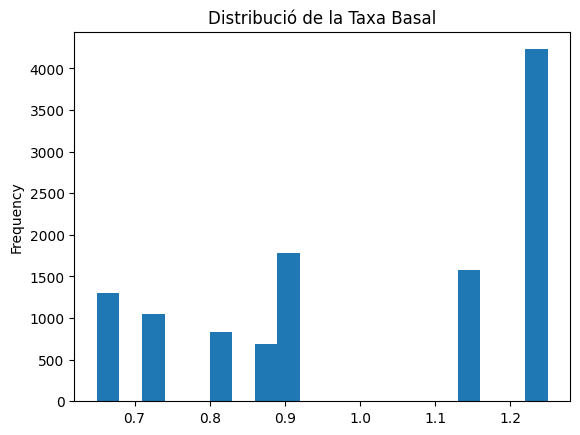

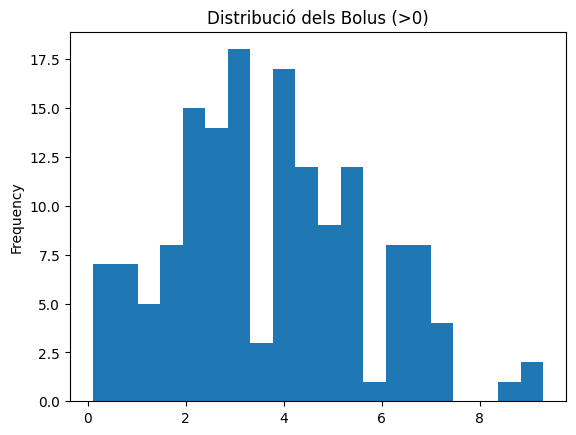

Percentatge de files amb bolus > 0: 1.25%


In [171]:
df_559_train['basal'].plot(kind='hist', bins=20, title='Distribució de la Taxa Basal')
plt.show()

df_559_train[df_559_train['bolus'] > 0]['bolus'].plot(kind='hist', bins=20, title='Distribució dels Bolus (>0)')
plt.show()
print(f"Percentatge de files amb bolus > 0: { (df_559_train['bolus'] > 0).mean() * 100:.2f}%")

Les columnes basal i bolus requereixen la conversió de format de text (amb coma decimal) a numèric, com es fa al preprocess. basal mostra uns pocs nivells discrets, típics de configuracions de bomba d'insulina. Bolus és majoritàriament zero, indicant que els bolus són esdeveniments puntuals (es la insulina administrada per el pacient puntualement)

#### Variable Objectiu

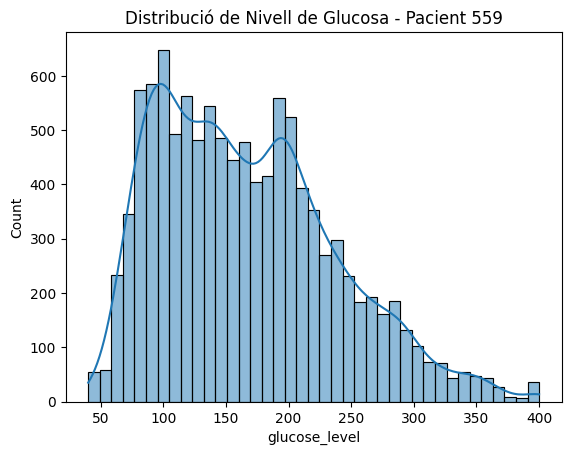

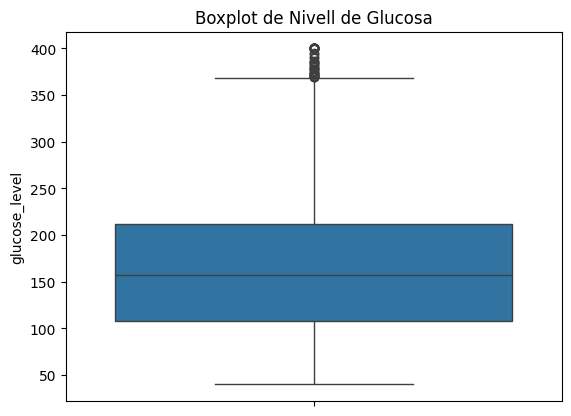

In [172]:
# Primer, tractem els zeros com a NaN abans de visualitzar
glucosa = df_559_train['glucose_level']
sns.histplot(glucosa, kde=True)
plt.title('Distribució de Nivell de Glucosa - Pacient 559')
plt.show()

sns.boxplot(y=glucosa)
plt.title('Boxplot de Nivell de Glucosa')
plt.show()

La distribució de glucose_level mostra un rang ampli de valors, amb una mitjana al voltant de 120-170 mg/dL. S'observen alguns valors extrems (possibles hiper/hipoglucèmies severes). El fet que inicialment hi hagués valors 0 justifica el pas de preprocessament on es reemplacen per NaN, ja que 0 no és un valor fisiològic per a la glucosa.

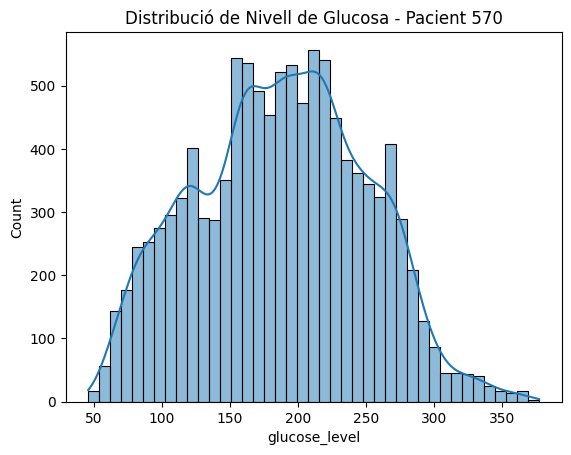

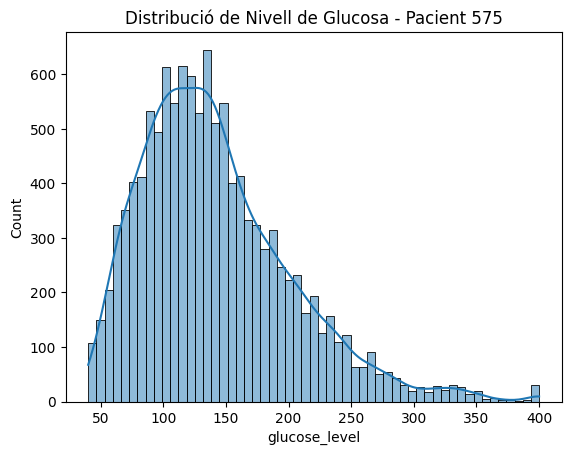

In [173]:
# Es interessant comparar aquest resultats amb la distribució en els pacient més problemàtics alhora de modelar per veure si hi ha diferències significatives
# El pacient un error baix és el 570 segons les proves fetes a offline_glucosa.ipynb
df_570_train = pd.read_csv('../data/570/570_train.csv', sep=';', header=None, names=cols)
df_570_train['glucose_level'] = df_570_train['glucose_level'].replace(0, np.nan)

glucosa_570 = df_570_train['glucose_level']
sns.histplot(glucosa_570, kde=True)
plt.title('Distribució de Nivell de Glucosa - Pacient 570')
plt.show()

# El pacient més problemàtic és el 575.
df_575_train = pd.read_csv('../data/575/575_train.csv', sep=';', header=None, names=cols)
df_575_train['glucose_level'] = df_575_train['glucose_level'].replace(0, np.nan)

glucosa_575 = df_575_train['glucose_level']
sns.histplot(glucosa_575, kde=True)
plt.title('Distribució de Nivell de Glucosa - Pacient 575')
plt.show()

#### Variables Temporals

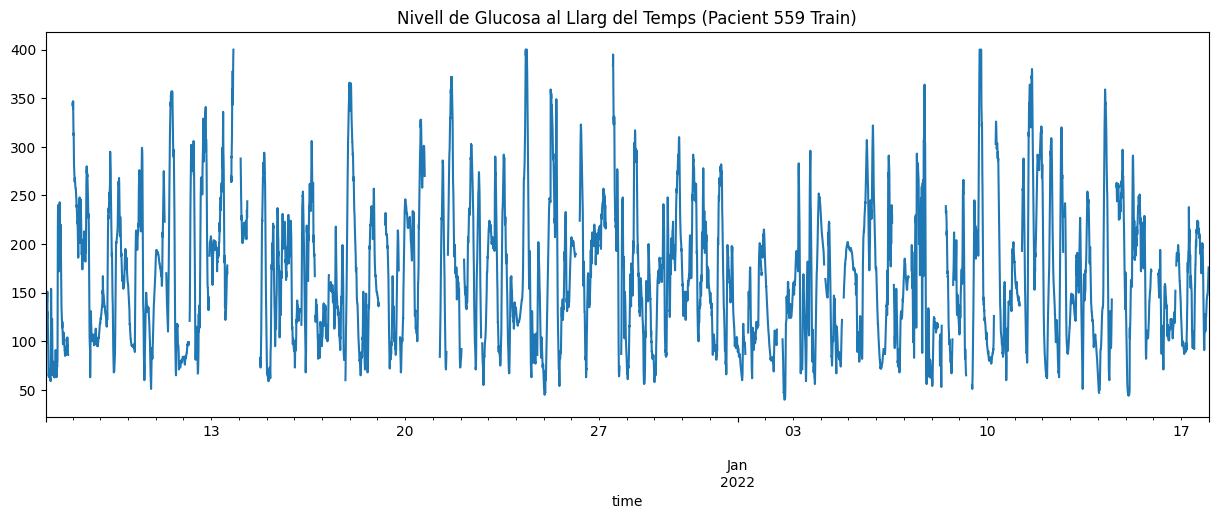

In [174]:
temp_df = df_559_train.copy()
temp_df['time'] = pd.to_datetime(temp_df[['year', 'month', 'day', 'hour', 'minute']])
temp_df.set_index('time')['glucose_level'].plot(figsize=(15,5), title='Nivell de Glucosa al Llarg del Temps (Pacient 559 Train)')
plt.show()


### Anàlisi de Variables Categòriques

In [175]:
print('Variables categoriques:\n\n', cat_col.tolist())
display(df_559_train[cat_col].head())

print(df_559_train[cat_col].value_counts())

Variables categoriques:

 ['meal_type']


,meal_type
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN


meal_type      
Desayuno           41
Cena               38
Almuerzo           34
Snack              27
Corrección hipo     7
Name: count, dtype: int64


Text(0.5, 1.0, 'MEAL TYPE')

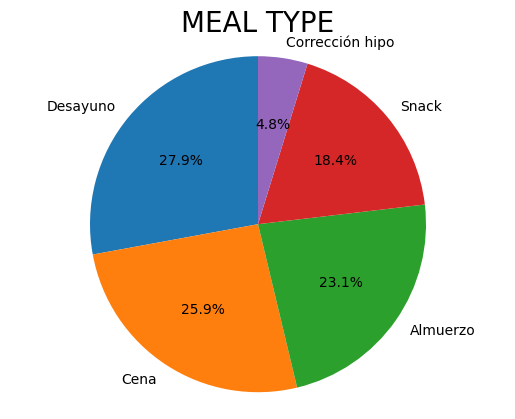

In [176]:
percent = df_559_train['meal_type'].value_counts()/df_559_train.shape[0]*100

plt.pie(percent, labels=percent.index, autopct='%1.1f%%', startangle=90)
plt.axis('equal')
plt.title('MEAL TYPE', size=20)

#### Visualitzacio de la resta de variables categoriques (definides com a numeriques ja per l'entrenament)

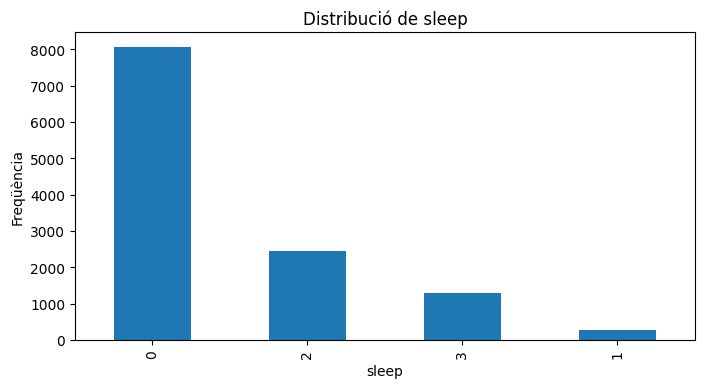

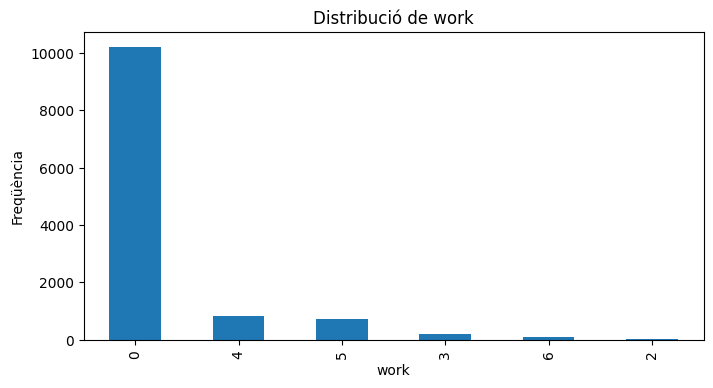

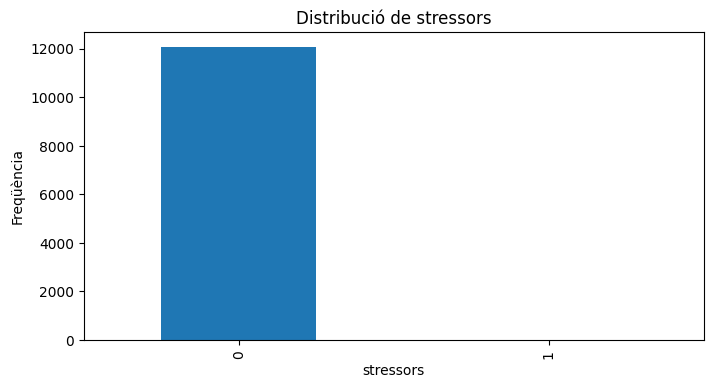

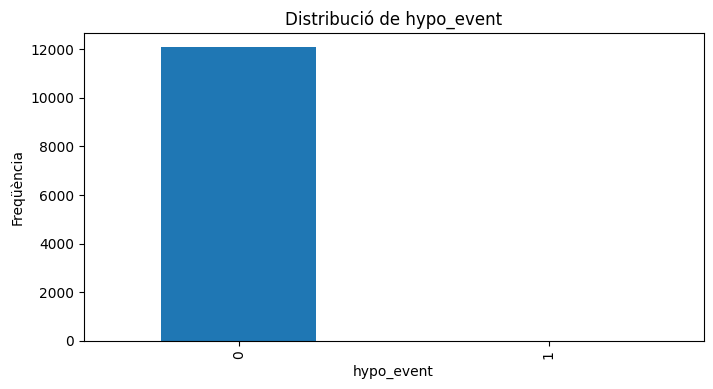

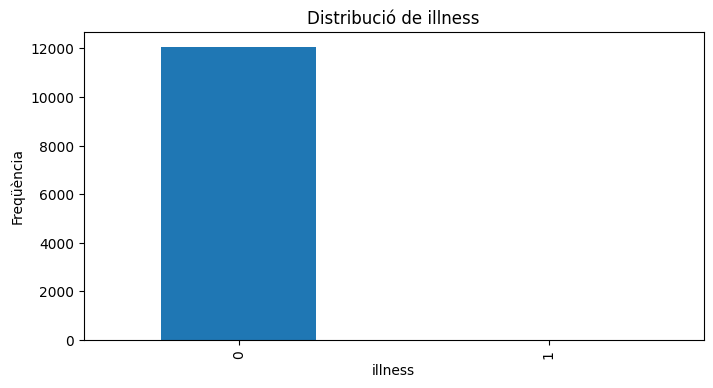

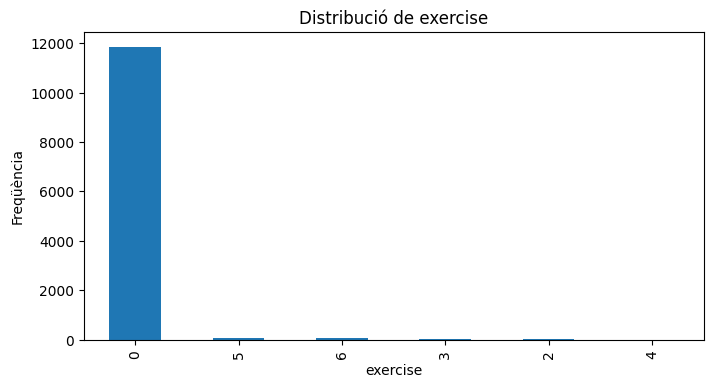

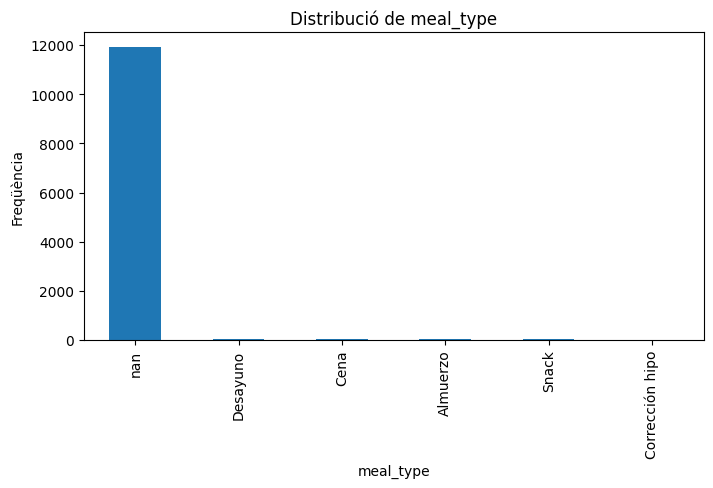

In [177]:
for col in ['sleep', 'work', 'stressors', 'hypo_event', 'illness', 'exercise', 'meal_type']:
    if col in df_559_train.columns:
        plt.figure(figsize=(8, 4))
        df_559_train[col].value_counts(dropna=False).plot(kind='bar')
        plt.title(f'Distribució de {col}')
        plt.ylabel('Freqüència')
        plt.show()

## Anàlisi Bivariada

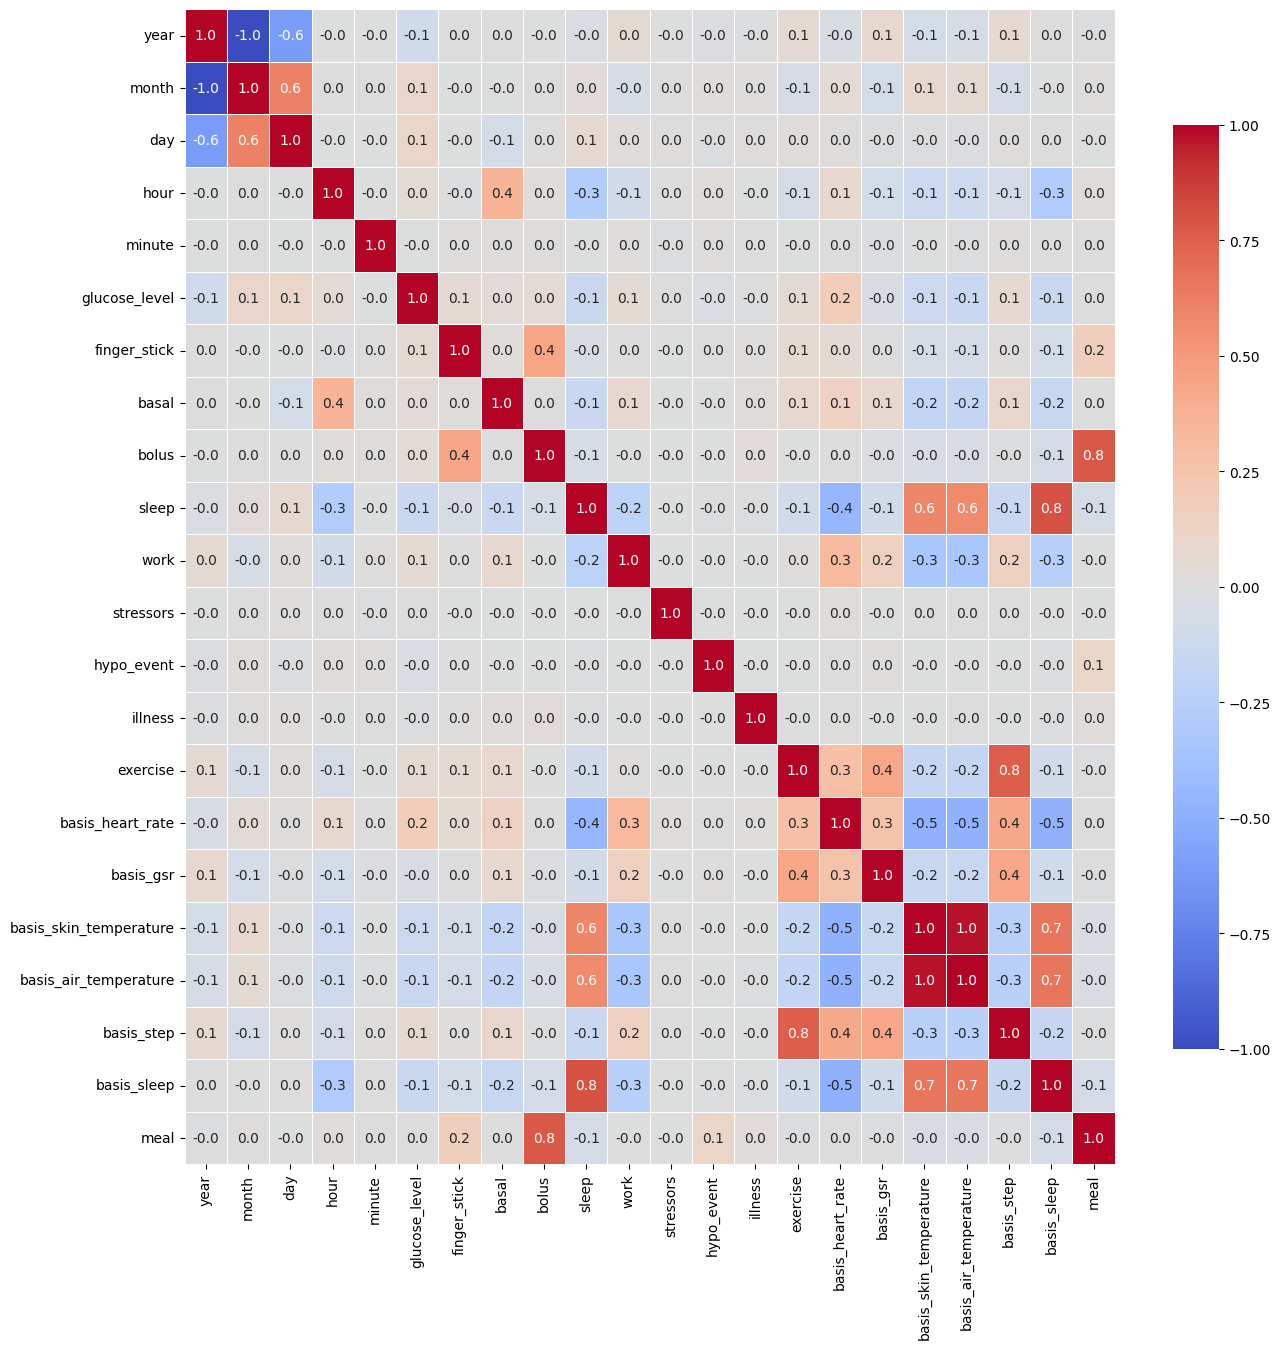

In [178]:
## Numèric vs Numèric: matriu de correlació + scatter de parelles fortes
corr = df_559_train[num_col].corr()

plt.figure(figsize=(15,15))
sns.heatmap(corr,annot=True, fmt=".1f", cmap="coolwarm", linewidths=.5, cbar_kws={"shrink": .8})
plt.show()

#### Glucosa vs variables discretes

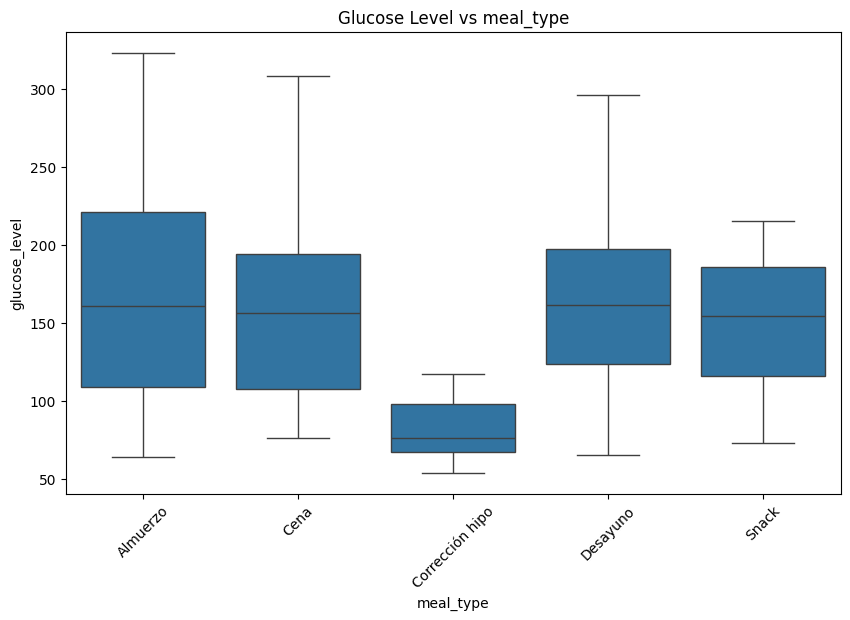

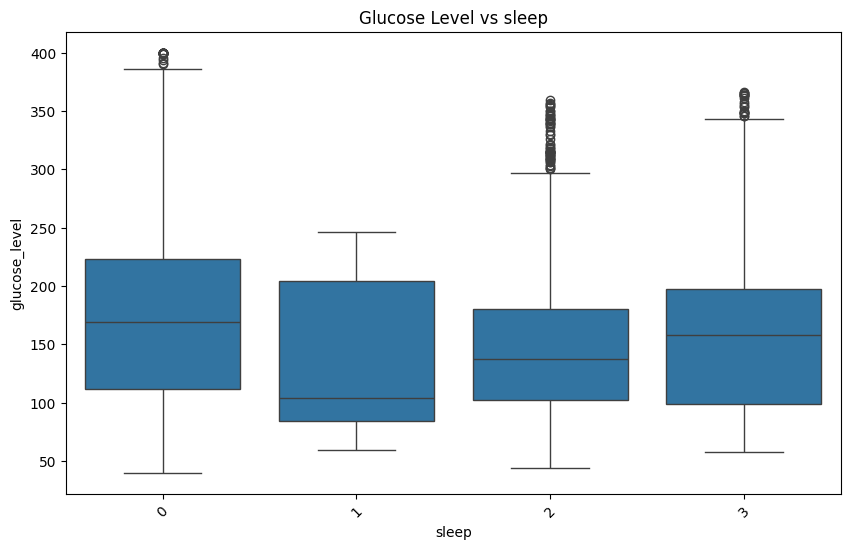

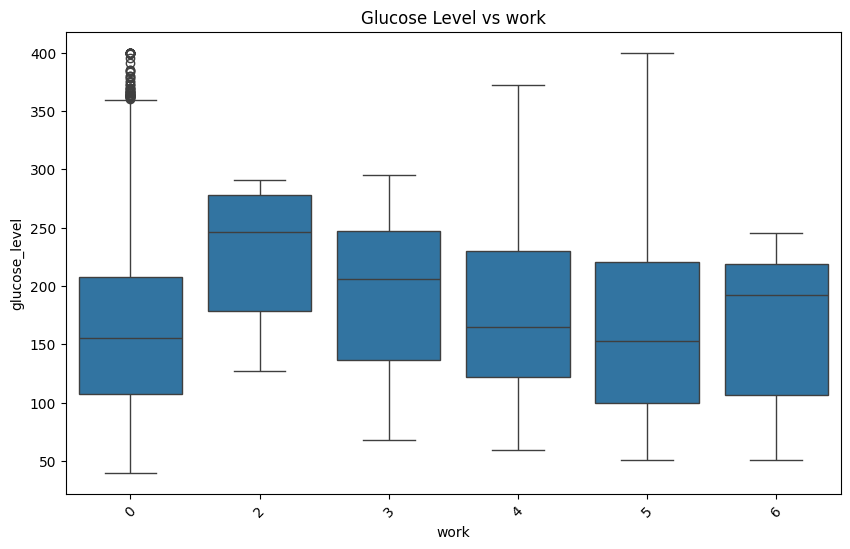

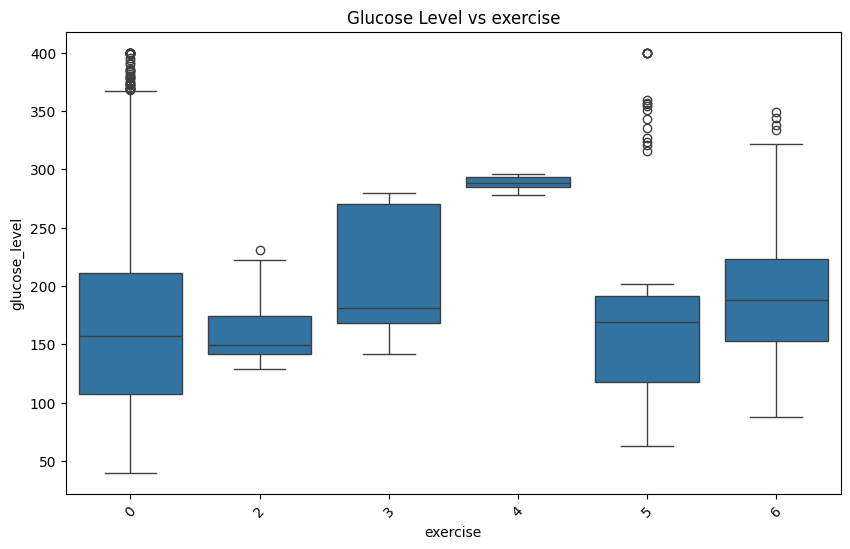

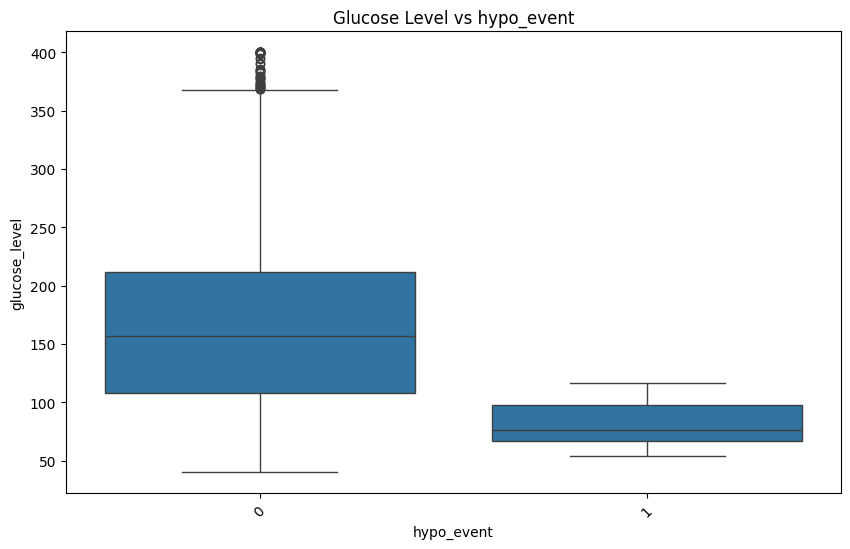

In [179]:
df_eda_bivariate = df_559_train.copy()

for cat_col_biv in ['meal_type', 'sleep', 'work', 'exercise', 'hypo_event']:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x=cat_col_biv, y='glucose_level', data=df_eda_bivariate)
    plt.title(f'Glucose Level vs {cat_col_biv}')
    plt.xticks(rotation=45)
    plt.show()